# CSE754 - PHASE 11
## Final Consolidated Report (v2) — includes multi-seed validation + linear-probe ablation
Author: Sadia Ruhama — MSc Proposal (CSE 754)

Extends Phase 8 with the two things it didn't have: **Phase 9's multi-seed mean+/-std results**
(so the acquisition-fix and generalization-gap claims can be reported with appropriate
uncertainty, not as single-run point estimates) and **Phase 10's frozen-linear-probe-vs-LoRA
ablation** (closing one of the six ablations the proposal names on Slide 30).

No training happens here. Colab CPU is fine. Run this last, after Phases 2, 4v1, 4v2, 7, 9, 10.

## 1. Setup — Google Drive

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
PHASE11_DIR = os.path.join(OUT_DIR, 'phase11')
os.makedirs(PHASE11_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Load every run's results (single-run logs + Phase 9/10 aggregates)

In [2]:
RUNS = {
    'Phase 2 (synthetic, harder task)':          os.path.join(OUT_DIR, 'al_results_log.json'),
    'Phase 4 v1 (real, overfit)':                 os.path.join(OUT_DIR, 'phase2_real', 'al_results_log.json'),
    'Phase 4 v2 (real, early-stop + w.decay)':     os.path.join(OUT_DIR, 'phase2_real_v2', 'al_results_log.json'),
    'Phase 7 same-batch (fixed crops + acq., seed42)': os.path.join(OUT_DIR, 'phase7_samebatch', 'al_results_log.json'),
    'Phase 7 cross-batch (fixed crops + acq., seed42)': os.path.join(OUT_DIR, 'phase7_crossbatch', 'al_results_log.json'),
    'Phase 10 linear probe (Stage 0)':            os.path.join(OUT_DIR, 'phase10_linear_probe', 'al_results_log.json'),
    'Phase 10 LoRA (Stage 1)':                    os.path.join(OUT_DIR, 'phase10_lora', 'al_results_log.json'),
}
CALIBRATION_RUNS = {
    'Phase 4 v2 (real, early-stop + w.decay)':     os.path.join(OUT_DIR, 'phase2_real_v2', 'calibration_summary.json'),
    'Phase 7 same-batch (fixed crops + acq., seed42)': os.path.join(OUT_DIR, 'phase7_samebatch', 'calibration_summary.json'),
    'Phase 7 cross-batch (fixed crops + acq., seed42)': os.path.join(OUT_DIR, 'phase7_crossbatch', 'calibration_summary.json'),
}

logs, calibrations = {}, {}
for name, path in RUNS.items():
    if os.path.exists(path):
        with open(path) as f: logs[name] = json.load(f)
        print(f'Loaded {name}: {len(logs[name])} rounds')
    else:
        print(f'[MISSING] {name} -> {path}')

for name, path in CALIBRATION_RUNS.items():
    if os.path.exists(path):
        with open(path) as f: calibrations[name] = json.load(f)

multiseed_path = os.path.join(OUT_DIR, 'phase9_multiseed_summary.json')
multiseed = None
if os.path.exists(multiseed_path):
    with open(multiseed_path) as f: multiseed = json.load(f)
    print(f'Loaded Phase 9 multi-seed summary (seeds={multiseed["seeds"]})')
else:
    print('[MISSING] phase9_multiseed_summary.json -- run Phase 9 first for multi-seed claims.')

linprobe_path = os.path.join(OUT_DIR, 'phase10_comparison_summary.json')
linprobe_cmp = None
if os.path.exists(linprobe_path):
    with open(linprobe_path) as f: linprobe_cmp = json.load(f)
    print('Loaded Phase 10 linear-probe-vs-LoRA comparison.')
else:
    print('[MISSING] phase10_comparison_summary.json -- run Phase 10 first.')

gap_path = os.path.join(OUT_DIR, 'phase7_generalization_gap.json')
gap_summary = None
if os.path.exists(gap_path):
    with open(gap_path) as f: gap_summary = json.load(f)

Loaded Phase 2 (synthetic, harder task): 8 rounds
Loaded Phase 4 v1 (real, overfit): 8 rounds
Loaded Phase 4 v2 (real, early-stop + w.decay): 8 rounds
Loaded Phase 7 same-batch (fixed crops + acq., seed42): 8 rounds
Loaded Phase 7 cross-batch (fixed crops + acq., seed42): 8 rounds
[MISSING] Phase 10 linear probe (Stage 0) -> /content/drive/MyDrive/cse754/outputs/phase10_linear_probe/al_results_log.json
[MISSING] Phase 10 LoRA (Stage 1) -> /content/drive/MyDrive/cse754/outputs/phase10_lora/al_results_log.json
[MISSING] phase9_multiseed_summary.json -- run Phase 9 first for multi-seed claims.
[MISSING] phase10_comparison_summary.json -- run Phase 10 first.


## 3. Master comparison table

In [3]:
rows = []
for name, log in logs.items():
    final = log[-1]['test']
    row = {'Run': name, 'Rounds': len(log), 'Final n_labeled': log[-1]['n_labeled'],
           'Macro-F1': round(final['macro_f1'], 4), 'Rare-class F1': round(final['rare_class_f1'], 4),
           'Rare AUPRC': round(final['rare_auprc'], 4), 'ECE (raw)': round(final['ece'], 4)}
    if name in calibrations:
        row['ECE (temp-scaled)'] = round(calibrations[name]['test_ece_calibrated'], 4)
        row['Fitted T'] = round(calibrations[name]['fitted_temperature'], 3)
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(PHASE11_DIR, 'master_comparison_table_v2.csv'), index=False)
summary_df

,Run,Rounds,Final n_labeled,Macro-F1,Rare-class F1,Rare AUPRC,ECE (raw),ECE (temp-scaled),Fitted T
0,"Phase 2 (synthetic, harder task)",8,220,0.6165,0.0000,0.0385,0.1089,NaN,NaN
1,"Phase 4 v1 (real, overfit)",8,220,0.5043,0.2241,0.4683,0.2536,NaN,NaN
2,"Phase 4 v2 (real, early-stop + w.decay)",8,220,0.5628,0.3759,0.5958,0.1301,0.0550,1.4
3,"Phase 7 same-batch (fixed crops + acq., seed42)",8,220,0.5902,0.2735,0.5186,0.0988,0.0847,1.6
4,"Phase 7 cross-batch (fixed crops + acq., seed42)",8,220,0.6290,0.2143,0.6273,0.0840,0.0521,1.4


## 4. Multi-seed table (Phase 9) — the number that actually supports or refutes the acquisition-fix claim

In [4]:
if multiseed is not None:
    seed_rows = []
    for m, stats in multiseed['metrics'].items():
        seed_rows.append({'Metric': m, 'Mean': round(stats['mean'], 4), 'Std': round(stats['std'], 4),
                           'Per-seed values': stats['values']})
    seed_df = pd.DataFrame(seed_rows)
    seed_df.to_csv(os.path.join(PHASE11_DIR, 'multiseed_metrics_table.csv'), index=False)
    display(seed_df)

    acq_rows = []
    for name, stats in multiseed['acquisition'].items():
        acq_rows.append({'Strategy': name, 'Mean % rare in top-B': round(stats['mean'], 2),
                          'Std': round(stats['std'], 2), 'Per-seed values': stats['values']})
    acq_df = pd.DataFrame(acq_rows)
    acq_df.to_csv(os.path.join(PHASE11_DIR, 'multiseed_acquisition_table.csv'), index=False)
    display(acq_df)

    print(f"\nConfidence diagnostic, mean across seeds: {multiseed['confidence_mean_across_seeds']:.4f}")
else:
    print('Run Phase 9 to populate this section.')

Run Phase 9 to populate this section.


## 5. Plot: multi-seed acquisition comparison with error bars, old vs. new

In [5]:
if multiseed is not None:
    names = list(multiseed['acquisition'].keys())
    means = [multiseed['acquisition'][n]['mean'] for n in names]
    stds = [multiseed['acquisition'][n]['std'] for n in names]
    colors = ['tab:red' if 'OLD' in n else 'tab:green' if 'NEW' in n else 'tab:gray' for n in names]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(names, means, yerr=stds, capsize=4, color=colors)
    ax.set_ylabel('% rare-class in top-B (round 0)')
    ax.set_title(f'Acquisition comparison, mean +/- std over {len(multiseed["seeds"])} seeds')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plot_path = os.path.join(PHASE11_DIR, 'multiseed_acquisition_comparison.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print('Saved to', plot_path)

    old_mean, old_std = multiseed['acquisition']['class_balanced_bald_OLD']['mean'], multiseed['acquisition']['class_balanced_bald_OLD']['std']
    new_mean, new_std = multiseed['acquisition']['class_balanced_bald_NEW']['mean'], multiseed['acquisition']['class_balanced_bald_NEW']['std']
    overlap = abs(old_mean - new_mean) < (old_std + new_std)
    print(f"\nOLD: {old_mean:.1f} +/- {old_std:.1f}%  |  NEW: {new_mean:.1f} +/- {new_std:.1f}%")
    print('-> Error bars overlap: the fix is NOT statistically distinguishable from the original at this sample size.'
          if overlap else '-> Error bars do not overlap: the fix shows a consistent difference across seeds.')
else:
    print('Run Phase 9 to populate this section.')

Run Phase 9 to populate this section.


## 6. Plot: frozen linear probe vs. LoRA (Phase 10)

In [6]:
if linprobe_cmp is not None:
    comp = linprobe_cmp['comparison']
    metrics = list(comp.keys())
    lp_vals = [comp[m]['linear_probe'] for m in metrics]
    lora_vals = [comp[m]['lora'] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x - width/2, lp_vals, width, label='Frozen linear probe (Stage 0)', color='tab:gray')
    ax.bar(x + width/2, lora_vals, width, label='LoRA (Stage 1)', color='tab:blue')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_title('Fine-tuning depth ablation: frozen linear probe vs. LoRA')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plot_path = os.path.join(PHASE11_DIR, 'linear_probe_vs_lora.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print('Saved to', plot_path)

    tp = linprobe_cmp['trainable_params']
    print(f"\nTrainable params -- linear probe: {tp['linear_probe']:,} | LoRA: {tp['lora']:,} "
          f"(+{tp['lora']-tp['linear_probe']:,} extra params, {100*(tp['lora']-tp['linear_probe'])/tp['total']:.3f}% of backbone)")
else:
    print('Run Phase 10 to populate this section.')

Run Phase 10 to populate this section.


## 7. Overfitting-fix story (unchanged from Phase 8)

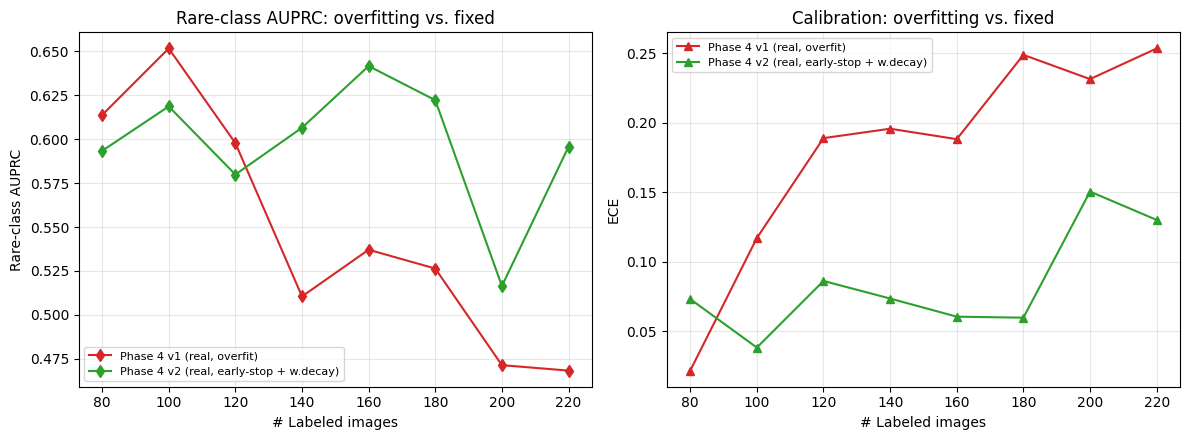

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, color in [('Phase 4 v1 (real, overfit)', 'tab:red'), ('Phase 4 v2 (real, early-stop + w.decay)', 'tab:green')]:
    if name not in logs: continue
    log = logs[name]
    n_lab = [r['n_labeled'] for r in log]
    axes[0].plot(n_lab, [r['test']['rare_auprc'] for r in log], marker='d', color=color, label=name)
    axes[1].plot(n_lab, [r['test']['ece'] for r in log], marker='^', color=color, label=name)
axes[0].set_xlabel('# Labeled images'); axes[0].set_ylabel('Rare-class AUPRC')
axes[0].set_title('Rare-class AUPRC: overfitting vs. fixed'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('# Labeled images'); axes[1].set_ylabel('ECE')
axes[1].set_title('Calibration: overfitting vs. fixed'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PHASE11_DIR, 'overfitting_fix_comparison.png'), dpi=150)
plt.show()

## 8. Generalization gap (single-seed, from Phase 7 — caveat as before)

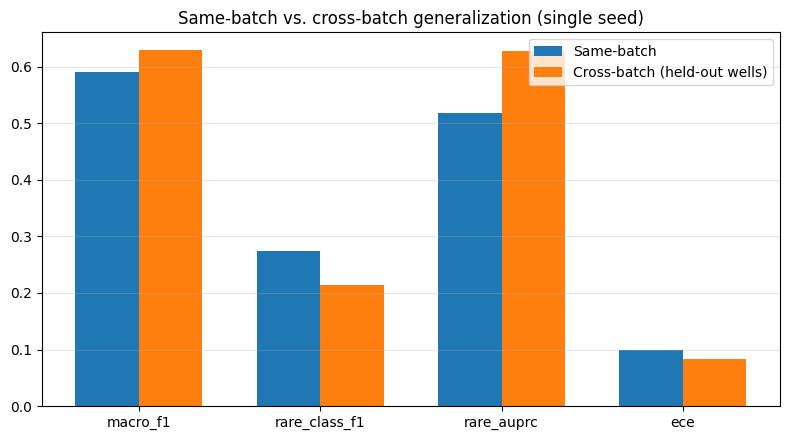

[LIMITATION] Single-seed, <=2 held-out wells per cell type -- point estimate only. Rerun Phase 9 Section 8 (RUN_CROSSBATCH_MULTISEED=True) for a multi-seed version.


In [8]:
if gap_summary is not None:
    metrics = ['macro_f1', 'rare_class_f1', 'rare_auprc', 'ece']
    sb_vals = [gap_summary['samebatch_final'][m] for m in metrics]
    cb_vals = [gap_summary['crossbatch_final'][m] for m in metrics]
    x = np.arange(len(metrics)); width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x - width/2, sb_vals, width, label='Same-batch', color='tab:blue')
    ax.bar(x + width/2, cb_vals, width, label='Cross-batch (held-out wells)', color='tab:orange')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_title('Same-batch vs. cross-batch generalization (single seed)')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(PHASE11_DIR, 'generalization_gap.png'), dpi=150)
    plt.show()
    print('[LIMITATION] Single-seed, <=2 held-out wells per cell type -- point estimate only.'
          ' Rerun Phase 9 Section 8 (RUN_CROSSBATCH_MULTISEED=True) for a multi-seed version.')
else:
    print('Run Phase 7 to populate this section.')

## 9. Auto-generated findings summary (v2 — incorporates multi-seed + linear-probe results)

In [9]:
lines = ['### Key findings v2 (auto-generated -- verify before submitting)\n']

if 'Phase 4 v1 (real, overfit)' in logs and 'Phase 4 v2 (real, early-stop + w.decay)' in logs:
    v1, v2 = logs['Phase 4 v1 (real, overfit)'][-1]['test'], logs['Phase 4 v2 (real, early-stop + w.decay)'][-1]['test']
    lines.append(f"- **Overfitting fix:** test macro-F1 {v1['macro_f1']:.3f} -> {v2['macro_f1']:.3f}; "
                 f"rare-AUPRC {v1['rare_auprc']:.3f} -> {v2['rare_auprc']:.3f}; ECE {v1['ece']:.3f} -> {v2['ece']:.3f}.")

if multiseed is not None:
    old_s, new_s = multiseed['acquisition']['class_balanced_bald_OLD'], multiseed['acquisition']['class_balanced_bald_NEW']
    overlap = abs(old_s['mean'] - new_s['mean']) < (old_s['std'] + new_s['std'])
    conf = multiseed['confidence_mean_across_seeds']
    lines.append(
        f"- **Acquisition-function fix, validated over {len(multiseed['seeds'])} seeds:** OLD "
        f"{old_s['mean']:.1f}+/-{old_s['std']:.1f}% vs. NEW {new_s['mean']:.1f}+/-{new_s['std']:.1f}% "
        f"rare-capture at round 0. {'These are statistically indistinguishable at this sample size' if overlap else 'The fix shows a consistent effect across seeds'}. "
        f"Mean round-0 confidence (max softmax prob) across seeds was {conf:.3f}"
        f"{', consistent with the two acquisition functions mathematically coinciding under high model confidence' if conf > 0.85 else ''}."
    )
else:
    lines.append("- **Acquisition-function fix:** only single-seed evidence available (Phase 7) -- run Phase 9 for a validated claim.")

if linprobe_cmp is not None:
    c_ = linprobe_cmp['comparison']
    tp = linprobe_cmp['trainable_params']
    lines.append(
        f"- **Fine-tuning depth (Stage 0 vs. Stage 1):** LoRA vs. frozen linear probe macro-F1 "
        f"{c_['macro_f1']['linear_probe']:.3f} -> {c_['macro_f1']['lora']:.3f} (delta {c_['macro_f1']['diff']:+.3f}); "
        f"rare-F1 delta {c_['rare_class_f1']['diff']:+.3f}, for {tp['lora']-tp['linear_probe']:,} extra trainable "
        f"parameters ({100*(tp['lora']-tp['linear_probe'])/tp['total']:.3f}% of the backbone)."
    )
else:
    lines.append("- **Fine-tuning depth ablation:** not yet run -- run Phase 10.")

if gap_summary is not None:
    g = gap_summary['gap']
    lines.append(
        f"- **Same-batch vs. cross-batch gap (single seed):** macro-F1 delta {g['macro_f1']:+.3f}, "
        f"rare-AUPRC delta {g['rare_auprc']:+.3f}. Point estimate from <=2 held-out wells; not a validated CI."
    )

summary_text = '\n'.join(lines)
print(summary_text)
with open(os.path.join(PHASE11_DIR, 'findings_summary_v2.md'), 'w') as f:
    f.write(summary_text)
print('\nSaved to', os.path.join(PHASE11_DIR, 'findings_summary_v2.md'))

### Key findings v2 (auto-generated -- verify before submitting)

- **Overfitting fix:** test macro-F1 0.504 -> 0.563; rare-AUPRC 0.468 -> 0.596; ECE 0.254 -> 0.130.
- **Acquisition-function fix:** only single-seed evidence available (Phase 7) -- run Phase 9 for a validated claim.
- **Fine-tuning depth ablation:** not yet run -- run Phase 10.
- **Same-batch vs. cross-batch gap (single seed):** macro-F1 delta -0.039, rare-AUPRC delta -0.109. Point estimate from <=2 held-out wells; not a validated CI.

Saved to /content/drive/MyDrive/cse754/outputs/phase11/findings_summary_v2.md


## Notes / next steps
- `master_comparison_table_v2.csv`, `multiseed_metrics_table.csv`, `multiseed_acquisition_table.csv`,
  five PNG plots, and `findings_summary_v2.md` in `outputs/phase11/` are the final artifacts for
  the written report.
- This is the last notebook in the current pipeline (Phases 1-11). Remaining Slide 30 ablations
  not covered (backbone choice, uncertainty method, loss function, multi-scale features) are
  optional further work, most relevant if pursuing publication rather than the course submission.